In [2]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 

PET shape: (64,)
First values: tf.Tensor([-0. -0. -0. -0. -0.], shape=(5,), dtype=float32)


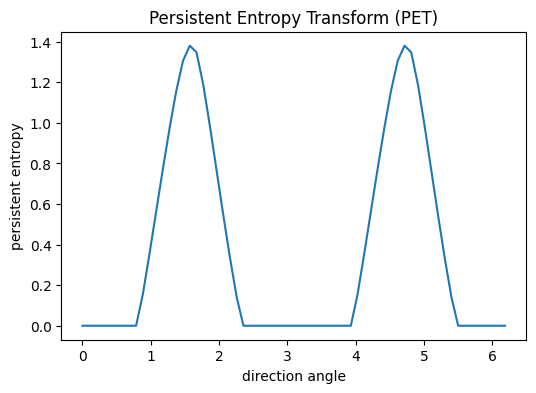

In [3]:
def generate_training_data(f, x_range, num_samples):
    x = np.linspace(*x_range, num_samples)
    y = np.array([f(xi) for xi in x])
    return x, y

# function for compute PE (without tensorflow, just for test the development in tensorflow) from persistence barcode
def computePersistenceEntropy(persistentBarcode):
    l=[]
    for i in persistentBarcode:
        l.append(i[1]-i[0])
    L = sum(l)
    p=l/L
    entropia=-np.sum(p*np.log(p))
    return entropia # round(entropia,4)

# Persistent entropy calculation in TensorFlow
def persistent_entropy(D):
    persistence = tf.experimental.numpy.diff(D)
    persistence = tf.boolean_mask(tf.abs(persistence), tf.math.is_finite(persistence))
    
    P = tf.reduce_sum(persistence)
    probabilities = persistence / P
    
    # Ensures that a probability of zero will result in a logarithm of zero as well
    log_prob = tf.zeros_like(probabilities)
    mask = probabilities > 0
    log_prob = tf.tensor_scatter_nd_update(log_prob, tf.where(mask), tf.math.log(probabilities[mask]))
    
    return -tf.reduce_sum(probabilities * log_prob)

# function for lower star persistencia diagram differentiable inside tensorflow
def LowerStarsSimplex(simplextree, filtration_values, dimensions, homology_coeff_field, persistence_dim_max):
    simplextree.reset_filtration(-np.inf, 0)

    # Assign new filtration values
    for i in range(simplextree.num_vertices()):
        simplextree.assign_filtration([i], filtration_values[i])
    simplextree.make_filtration_non_decreasing()
    
    # Compute persistence diagram
    simplextree.compute_persistence(homology_coeff_field=homology_coeff_field, persistence_dim_max=persistence_dim_max)
    
    # Get vertex pairs for optimization. First, get all simplex pairs
    pairs = simplextree.lower_star_persistence_generators()
    
    L_indices = []
    for dimension in dimensions:
    
        finite_pairs = pairs[0][dimension] if len(pairs[0]) >= dimension+1 else np.empty(shape=[0,2])
        finite_pairs = np.vstack((finite_pairs,[np.argmin(filtration_values).item(),np.argmax(filtration_values).item()]))
        essential_pairs = pairs[1][dimension] if len(pairs[1]) >= dimension+1 else np.empty(shape=[0,1])
        
        finite_indices = np.array(finite_pairs.flatten(), dtype=np.int32)
        essential_indices = np.array(essential_pairs.flatten(), dtype=np.int32)

        L_indices.append((finite_indices, essential_indices))

    return L_indices

class LowerStarLayer(tf.keras.layers.Layer):
    def __init__(self, simplextree, homology_dimensions=[0], min_persistence=None, homology_coeff_field=11, persistence_dim_max=0, **kwargs):
        super().__init__(**kwargs)
        self.dimensions  = homology_dimensions
        self.simplextree = simplextree
        self.min_persistence = min_persistence if min_persistence is not None else [0. for _ in range(len(self.dimensions))]
        self.hcf = homology_coeff_field
        self.pdm = persistence_dim_max
        assert len(self.min_persistence) == len(self.dimensions)
        
    def call(self, filtration_values):
        indices = LowerStarsSimplex(self.simplextree, filtration_values.numpy(), self.dimensions, self.hcf, self.pdm)
        # Get persistence diagrams
        self.dgms = []
        for idx_dim, dimension in enumerate(self.dimensions):
            finite_dgm = tf.reshape(tf.gather(filtration_values, indices[idx_dim][0]), [-1,2])
            essential_dgm = tf.reshape(tf.gather(filtration_values, indices[idx_dim][1]), [-1,1])
            min_pers = self.min_persistence[idx_dim]
            if min_pers >= 0:
                persistent_indices = tf.where(tf.math.abs(finite_dgm[:,1]-finite_dgm[:,0]) > min_pers)
                self.dgms.append((tf.reshape(tf.gather(finite_dgm, indices=persistent_indices),[-1,2]), essential_dgm))
            else:
                self.dgms.append((finite_dgm, essential_dgm))
        return self.dgms

def generate_directions_2D(num_directions):
    """
    Generate unit directions on S^1
    """
    angles = np.linspace(0.0, 2*np.pi, num_directions, endpoint=False)
    directions = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    return tf.constant(directions, dtype=tf.float32), angles

def directional_height_function(x, y, direction):
    """
    Compute directional height function:
        h = <(x,y), v>
    """
    vx, vy = direction[0], direction[1]
    return vx * x + vy * y

def persistent_entropy_transform(
        x_coords,
        y_coords,
        lower_star_layer,
        num_directions=32):
    """
    Compute Persistent Entropy Transform (PET)

    Returns:
        pet_values : Tensor (num_directions,)
        angles     : sampled directions
    """

    directions, angles = generate_directions_2D(num_directions)

    pet_values = []

    for k in range(num_directions):

        direction = directions[k]

        # ---- Directional filtration ----
        filtration_values = directional_height_function(
            x_coords,
            y_coords,
            direction
        )

        # ---- Persistence diagram ----
        dgms = lower_star_layer.call(filtration_values)
        dgm = dgms[0][0]  # H0 diagram

        # ---- Persistent entropy ----
        pe = persistent_entropy(dgm)

        pet_values.append(pe)

    pet_values = tf.stack(pet_values)

    return pet_values, angles

domain =[-10,10]
function=np.sin
n_points = 1000
x_train, y_train = generate_training_data(function, (domain[0], domain[1]), n_points)
x_train = tf.constant(x_train,dtype=tf.float32)
y_train = tf.constant(y_train,dtype=tf.float32)

stbase = gd.SimplexTree()
for i in range(n_points-1):
    stbase.insert([i,i+1], -1e10)
layer = LowerStarLayer(simplextree=stbase)

dgmsRef = layer.call(y_train)
dgmRef = dgmsRef[0][0]
PERef=persistent_entropy(dgmRef)

PET_values, angles = persistent_entropy_transform(
    x_train,
    y_train,
    layer,
    num_directions=64
)

print("PET shape:", PET_values.shape)
print("First values:", PET_values[:5])


plt.figure(figsize=(6,4))
plt.plot(angles, PET_values.numpy())
plt.xlabel("direction angle")
plt.ylabel("persistent entropy")
plt.title("Persistent Entropy Transform (PET)")
plt.show()

In [4]:
PET_values

<tf.Tensor: shape=(64,), dtype=float32, numpy=
array([-0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        ,  0.15379816,
        0.35478458,  0.5648196 ,  0.7744694 ,  0.9761119 ,  1.1595925 ,
        1.3070611 ,  1.3805673 ,  1.3483145 ,  1.1900604 ,  0.9845997 ,
        0.7647494 ,  0.54476887,  0.33326125,  0.14040907, -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        ,  0.15379816,  0.35478458,  0.5648196 ,  0.7744694 ,
        0.9761119 ,  1.1595925 ,  1.3070611 ,  1.3805673 ,  1.3483145 ,
        1.1900604 ,  0.9845997 ,  0.7647494 ,  0.54476887,  0.33326125,
        0.14040907, -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        ], dtype=float32)>

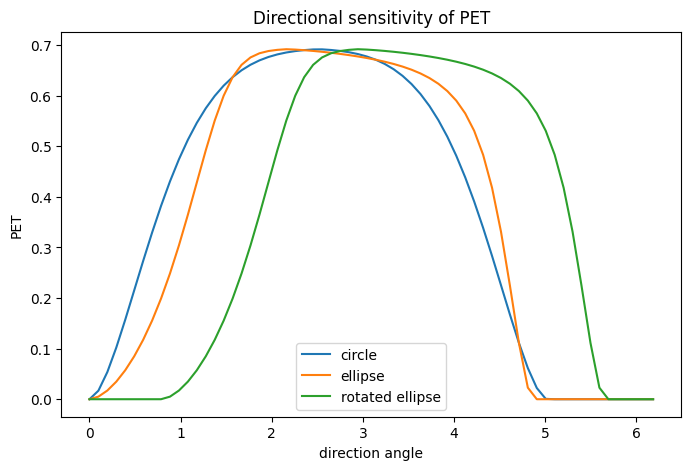


=== Experiment 2: Noise robustness ===
sigma=0.00 -> distance=0.0000
sigma=0.06 -> distance=28.8277
sigma=0.11 -> distance=32.3055
sigma=0.17 -> distance=32.9232
sigma=0.22 -> distance=33.4342
sigma=0.28 -> distance=33.6908
sigma=0.33 -> distance=33.7453
sigma=0.39 -> distance=33.6982
sigma=0.44 -> distance=33.6283
sigma=0.50 -> distance=34.1605


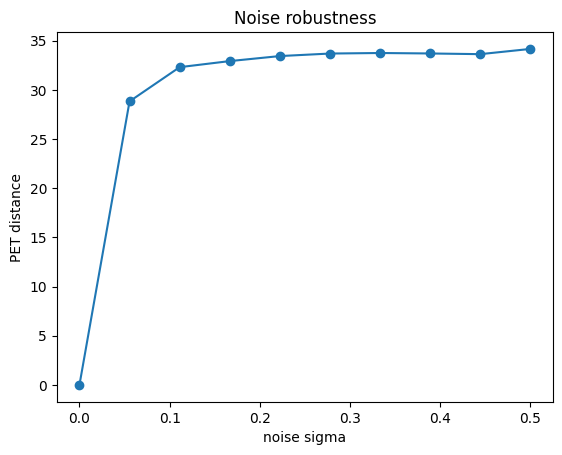

In [6]:

# ---------- SHAPE GENERATORS ----------

def generate_circle(n_points=500, radius=1.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = radius * np.cos(t)
    y = radius * np.sin(t)
    return x, y


def generate_ellipse(n_points=500, a=2.0, b=1.0, rotation=0.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = a * np.cos(t)
    y = b * np.sin(t)

    R = np.array([
        [np.cos(rotation), -np.sin(rotation)],
        [np.sin(rotation),  np.cos(rotation)]
    ])

    pts = R @ np.vstack([x, y])
    return pts[0], pts[1]


def generate_noisy_shape(x, y, sigma):
    noise_x = np.random.normal(0, sigma, len(x))
    noise_y = np.random.normal(0, sigma, len(y))
    return x + noise_x, y + noise_y

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles

def experiment_directional_sensitivity(layer):

    shapes = {
        "circle": generate_circle(),
        "ellipse": generate_ellipse(a=2, b=1),
        "rotated ellipse": generate_ellipse(a=2, b=1, rotation=np.pi/4)
    }

    plt.figure(figsize=(8,5))

    for name, (x, y) in shapes.items():
        pet, angles = compute_pet_from_shape(x, y, layer)
        plt.plot(angles, pet, label=name)

    plt.legend()
    plt.xlabel("direction angle")
    plt.ylabel("PET")
    plt.title("Directional sensitivity of PET")
    plt.show()

def experiment_noise_stability(layer):

    print("\n=== Experiment 2: Noise robustness ===")

    x,y = generate_ellipse(a=2,b=1)
    pet_clean,_ = compute_pet_from_shape(x,y,layer)

    sigmas = np.linspace(0,0.5,10)
    distances = []

    for sigma in sigmas:
        xn,yn = generate_noisy_shape(x,y,sigma)
        pet_noisy,_ = compute_pet_from_shape(xn,yn,layer)

        dist = np.linalg.norm(pet_clean - pet_noisy)
        distances.append(dist)

        print(f"sigma={sigma:.2f} -> distance={dist:.4f}")

    plt.figure()
    plt.plot(sigmas, distances, marker="o")
    plt.xlabel("noise sigma")
    plt.ylabel("PET distance")
    plt.title("Noise robustness")
    plt.show()


n_points = 400
layer = build_lowerstar_layer(n_points)

# Run all experiments
experiment_directional_sensitivity(layer)
experiment_noise_stability(layer)

In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def build_dataset(layer, n_samples=20):

    X=[]
    y_labels=[]

    for _ in range(n_samples):
        x,y = generate_circle()
        pet,_ = compute_pet_from_shape(x,y,layer)
        X.append(pet)
        y_labels.append(0)

    for _ in range(n_samples):
        x,y = generate_ellipse(a=2,b=1)
        pet,_ = compute_pet_from_shape(x,y,layer)
        X.append(pet)
        y_labels.append(1)

    return np.array(X), np.array(y_labels)


def experiment_classification(layer):

    print("\n=== Experiment 3: Classification ===")

    X,y = build_dataset(layer)

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.3,random_state=0
    )

    clf = SVC(kernel="linear")
    clf.fit(X_train,y_train)

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test,preds)

    print("Classification accuracy:",acc)

experiment_classification(layer)


=== Experiment 3: Classification ===
Classification accuracy: 1.0


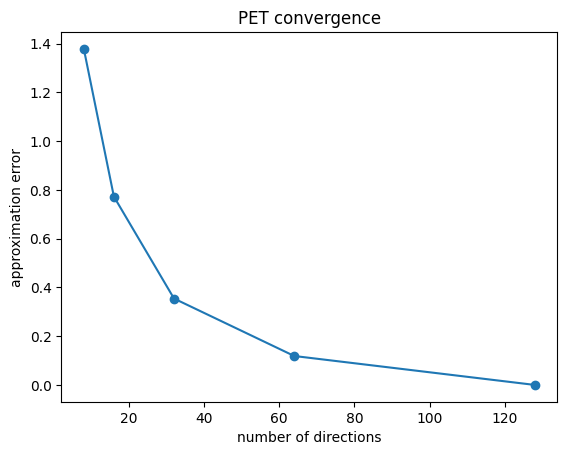

In [10]:
def experiment_direction_sampling(layer):

    x, y = generate_ellipse(a=2, b=1)

    dirs = [8,16,32,64,128]
    reference,_ = compute_pet_from_shape(x,y,layer,128)

    errors = []

    for d in dirs:
        pet,_ = compute_pet_from_shape(x,y,layer,d)
        interp = np.interp(
            np.linspace(0,1,len(reference)),
            np.linspace(0,1,len(pet)),
            pet
        )

        err = np.linalg.norm(reference - interp)
        errors.append(err)

    plt.figure()
    plt.plot(dirs, errors, marker="o")
    plt.xlabel("number of directions")
    plt.ylabel("approximation error")
    plt.title("PET convergence")
    plt.show()

experiment_direction_sampling(layer)

In [11]:
import time

def experiment_runtime(layer):

    x, y = generate_ellipse()

    for dirs in [8,16,32,64]:
        start = time.time()
        compute_pet_from_shape(x,y,layer,dirs)
        elapsed = time.time() - start

        print(f"Directions={dirs}, time={elapsed:.3f}s")

experiment_runtime(layer)

Directions=8, time=0.041s
Directions=16, time=0.064s
Directions=32, time=0.153s
Directions=64, time=0.290s
